# MOCS II Final Project Work
## StS -- Modeling Encounter Outcomes
## Alex Stute

In [1]:
from itertools import permutations
import numpy as np
import matplotlib.pyplot as plt
plt.style.use(['ggplot'])

Things to track in an encounter:
- Enemy health
- Player health
- Damage and block values on cards

Start off simple: Tracking possible damage/block values based on cards drawn

Starting deck:
- 5 Strikes (6 Damage)
  - Tracked using `x`
- 4 Defends (5 Block)
  - Tracked using `y`
- 1 Bash (8 Damage + 2 Vulnerable)
  - Vulnerable is a status/condition that increases damage taken by 50% for the number of turns equal to the condition number
  - Tracked using a dictionary in the python code itself

In [ ]:
# Define the cards
# Data is stored as (Cost, (Effect Types), (Effect Values))
all_cards = {'Strike': (1, ('Damage'), (6)),
             'Defend': (1, ('Block'), (5)),
             'Bash': (2, ('Damage', 'Vulnerable'), (8, 2))}

# The initial deck
starting_deck = {'Strike': 5, 'Defend': 4, 'Bash': 1}

# Current cards in hand
hand = []

# Current cards in deck
current_deck = starting_deck.copy()

# Current cards in discard
current_discard = starting_deck.copy()

for card in current_discard:
    current_discard[card] = 0

# Draw cards from deck
def draw_cards(current_deck, current_discard, hand, num_draw):
    # Draw num_draw cards and add them to hand
    for n in range(0,num_draw):
        # Get how many cards are in the deck
        deck_count = sum(current_deck.values())
        
        # If the deck is empty, shuffle the discard pile into the draw pile
        if deck_count == 0:
            current_deck = current_discard.copy()
            current_discard = starting_deck.copy()
            for card in current_discard:
                current_discard[card] = 0
            deck_count = sum(current_deck.values())

        # print(current_deck)
        # Get what types of cards can be drawn and at what probabilities
        types = list(current_deck.keys())
        probs = [current_deck[t] / deck_count for t in types]

        # Pick a card at random from deck and add it to hand
        card = np.random.choice(types, p=probs)
        hand.append({str(card): all_cards[card]})

        # Remove the drawn card from the deck
        current_deck[str(card)] -= 1

    return current_deck, current_discard, hand

# Find all playable permutations of cards
# returns a list of all possible permutations of card plays
def calc_playable(hand, energy):
    all_possible_plays = []
    all_perms = list(permutations(hand))

    # for each permutation
    for p in all_perms:
        count = 0
        curr_played = []
        available_energy = energy
        # while there are still cards to check
        while count < len(p):
            # if the current card costs less than or has cost equal to
            # the current amount of energy available
            if list(p[count].values())[0][0] <= available_energy:
                # "play" the card and move to the next card
                curr_played.append(p[count])
                available_energy = available_energy - list(p[count].values())[0][0]
                count += 1
            else:
                # otherwise, move to the next card
                count += 1
        # once all cards are checked or energy runs out, add possible played cards to list
        # only add if not already present to save space
        if curr_played not in all_possible_plays:
            all_possible_plays.append(curr_played)

    return all_possible_plays

# Print all cards in hand nicely
def pretty_print_hand(cards):
    count = 1
    for c in cards:
        print(f'Card {count}: {list(c.keys())[0]} -- Cost: {list(c.values())[0][0]}' + 
               f' Effect: {list(c.values())[0][1]} {list(c.values())[0][2]}')
        count += 1

# Print all possible permutations of cards nicely
def pretty_print_perms(perms):
    for p in perms:
        pretty_print_hand(p)
        print()

current_deck, current_discard, hand = draw_cards(starting_deck, current_discard, hand, 5)

all_possible_plays = calc_playable(hand,3)

pretty_print_hand(hand)

# pretty_print_perms(all_possible_plays)

Card 1: Defend -- Cost: 1 Effect: Block 5
Card 2: Strike -- Cost: 1 Effect: Damage 6
Card 3: Bash -- Cost: 2 Effect: ('Damage', 'Vulnerable') (8, 2)
Card 4: Strike -- Cost: 1 Effect: Damage 6
Card 5: Strike -- Cost: 1 Effect: Damage 6


Calculate possible damage/block values for the given hand

Currently a random prob/chance for each permutation

In [3]:
# Create the PGFs for the effect(s) of cards
def card_pgf(card_name, x, y, states):
    vuln = states.get('vulnerable', 0)
    vuln_mult = 1.5 if vuln > 0 else 1.0

    if card_name == 'Strike':
        return x**(6*vuln_mult)
    elif card_name == 'Defend':
        return y**5
    elif card_name == 'Bash':
        return x**(8*vuln_mult)
    else:
        raise ValueError(f"Invalid Card Name {card_name}")

# Create a PGF that plays the card permutations with specified probabilities
# start with completely random / no preference
def plays_pgf(hand, energy, x, y):
    all_possible_plays = calc_playable(hand, energy)
    prob = 1 / len(all_possible_plays) # each permutation has equal prob of being selected
    total = 0
    for play in all_possible_plays:
        # Product of PGFs for each card played
        pgf = 1
        # Track game state/statuses over each card play
        states = {'vulnerable': 0}
        for card in play:
            pgf *= card_pgf(list(card.keys())[0], x, y, states)
            states = apply_card_to_state(list(card.keys())[0], states)
        total += prob * pgf
    return total

def apply_card_to_state(card_name, states):
    # Return updated state after playing a card
    new_states = states.copy()
    if card_name == 'Bash':
        new_states['vulnerable'] = new_states.get('vulnerable', 0) + 2
    # Add other state-modifying cards here
    return new_states

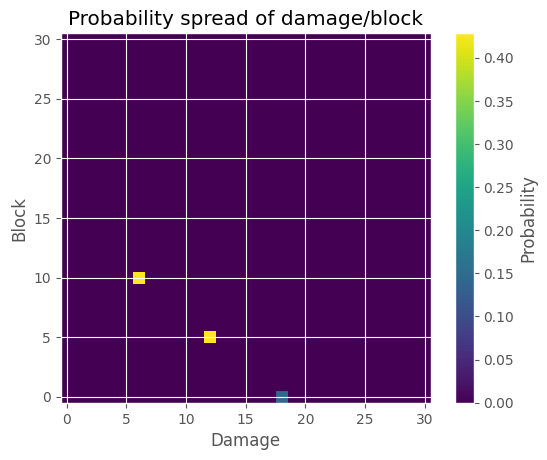

In [10]:
dmg_max = 31
blk_max = 31
dmg_vals = np.arange(dmg_max)
blk_vals = np.arange(blk_max)

dmg = np.exp(2*np.pi*1j*dmg_vals/dmg_max)
blk = np.exp(2*np.pi*1j*blk_vals/blk_max)

DMG, BLK = np.meshgrid(dmg, blk)

# M evaluated pointwise over the grid
M_grid = np.zeros((blk_max, dmg_max), dtype=complex)
for i in range(blk_max):
    for j in range(dmg_max):
        M_grid[i, j] = plays_pgf(hand, energy=3, x=dmg[j], y=blk[i])

pn1n2 = abs(np.fft.fft2(M_grid)) / (blk_max * dmg_max)

plt.imshow(pn1n2, origin='lower')
plt.colorbar(label='Probability')
plt.ylabel('Block')
plt.xlabel('Damage')
plt.title("Probability spread of damage/block")
plt.show()

Now we implement the enemy damage

The basic enemy we will implement is a cultist:
- First turn it deals no damage
- Second turn it attacks for 6 damage
- Third turn it attacks for 11 damage
- Fourth turn it attacks for 16 damage

And so on and so forth...

In [6]:
def cultist_pgf(turn, y):
    # Turn 1 do nothing
    if turn == 0:
        return 1
    # Every other turn deal 1 + multiple of 5
    # Use negative block to show enemy damage
    # In the end, negative block count -> player hp damage
    else:
        return y**((-5)*turn - 1)


Now we want to incorporate this with our `plays_pgf()` function

In [7]:
def plays_pgf_enemy(enemy_pgf, turn, hand, energy, x, y):
    all_possible_plays = calc_playable(hand, energy)
    prob = 1 / len(all_possible_plays) # each permutation has equal prob of being selected
    total = 0
    for play in all_possible_plays:
        # Product of PGFs for each card played
        pgf = 1
        states = {'vulnerable': 0}
        for card in play:
            pgf *= card_pgf(list(card.keys())[0], x, y, states)
            states = apply_card_to_state(list(card.keys())[0], states)
        pgf *= enemy_pgf(turn, y)
        total += prob * pgf
    return total

Testing

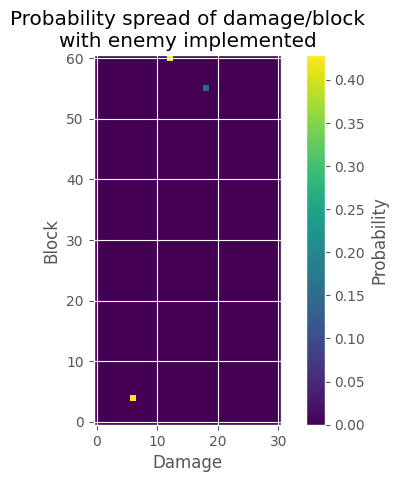

In [11]:
current_turn = 1
max_hp = 30
curr_hp = 30

dmg_max = 31
blk_max = 2 * max_hp + 1
dmg_vals = np.arange(dmg_max)
blk_vals = np.arange(blk_max)

dmg = np.exp(2*np.pi*1j*dmg_vals/dmg_max)
blk = np.exp(2*np.pi*1j*blk_vals/blk_max)

DMG, BLK = np.meshgrid(dmg, blk)

# M evaluated pointwise over the grid
M_grid = np.zeros((blk_max, dmg_max), dtype=complex)
for i in range(blk_max):
    for j in range(dmg_max):
        M_grid[i, j] = plays_pgf_enemy(cultist_pgf, current_turn, hand, energy=3, x=dmg[j], y=blk[i])

pn1n2 = abs(np.fft.fft2(M_grid)) / (blk_max * dmg_max)

plt.imshow(pn1n2, origin='lower')
plt.colorbar(label='Probability')
plt.ylabel('Block')
plt.xlabel('Damage')
plt.title("Probability spread of damage/block\nwith enemy implemented")
plt.show()

Want to shift everything up by max health so that looping around does not occur

In [12]:
def shift(array, amt):
    return np.roll(array, amt, 0).tolist()

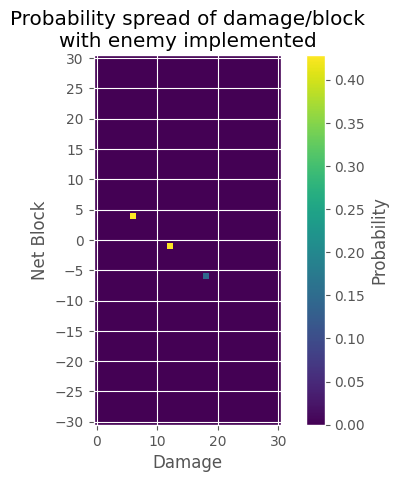

In [13]:
pn1n2_fixed = shift(pn1n2, max_hp)
# After doing the shift, have to add max_hp to the index to get the proper value
# To get the prob of blocking 4 and dealing 6: pn1n2_fixed[4+max_hp][6]
plt.imshow(pn1n2_fixed, origin='lower', extent=[-0.5, dmg_max - 0.5, -max_hp - 0.5, max_hp + 0.5])
plt.colorbar(label='Probability')
ax = plt.gca()
ax.set_yticks(range(-max_hp,max_hp+1,5))
plt.ylabel('Net Block')
plt.xlabel('Damage')
plt.title("Probability spread of damage/block\nwith enemy implemented")
plt.show()

Randomly choose which "path" is used

This should practically always return one of the highlighted possibilities since the sea of purple is so small (scale of $1*10^{-18}$)

In [14]:
def sample_prob(p):
    p_array = np.array(p)
    i = np.random.choice(np.arange(p_array.size), p=p_array.ravel())
    return np.unravel_index(i, p_array.shape)

Run a completely random simulated encounter

In [15]:
def end_turn(hand):
    for card in range(len(hand)):
        card_name = list(hand[card].keys())[0]
        current_discard[card_name] = current_discard[card_name]+1
    hand = []
    return hand, current_discard

In [33]:
def main(hand, current_deck, current_discard, max_hp, curr_hp, enemy_hp, enemy_pgf):
    player_hp_change = [curr_hp]
    enemy_hp_change = [enemy_hp]
    current_turn = 1
    while curr_hp > 0 and enemy_hp > 0:
        current_deck, current_discard, hand = draw_cards(current_deck, current_discard, hand, 5)
        all_possible_plays = calc_playable(hand,3)

        dmg_max = 31
        blk_max = 2 * max_hp + 1
        dmg_vals = np.arange(dmg_max)
        blk_vals = np.arange(blk_max)

        dmg = np.exp(2*np.pi*1j*dmg_vals/dmg_max)
        blk = np.exp(2*np.pi*1j*blk_vals/blk_max)

        DMG, BLK = np.meshgrid(dmg, blk)

        # M evaluated pointwise over the grid
        M_grid = np.zeros((blk_max, dmg_max), dtype=complex)
        for i in range(blk_max):
            for j in range(dmg_max):
                M_grid[i, j] = plays_pgf_enemy(enemy_pgf, current_turn, hand, energy=3, x=dmg[j], y=blk[i])

        pn1n2 = abs(np.fft.fft2(M_grid)) / (blk_max * dmg_max)
        pn1n2_fixed = shift(pn1n2, max_hp)

        block, damage = sample_prob(pn1n2_fixed)
        block = block - max_hp

        enemy_hp -= damage

        enemy_hp_change.append(enemy_hp)

        # If enemy dies, it does not attack
        if enemy_hp < 0:
            break

        if block < 0:
            curr_hp += block
        
        player_hp_change.append(curr_hp)
    
        current_turn += 1

        hand, current_discard = end_turn(hand)

    # print(f'Turns taken: {current_turn}')
    # print(f'Player HP: {curr_hp}')
    # print(f'Enemy HP: {enemy_hp}')

    return current_turn, curr_hp, player_hp_change, enemy_hp_change

In [ ]:
# Define the cards
# Data is stored as (Cost, (Effect Types), (Effect Values))
all_cards = {'Strike': (1, ('Damage'), (6)),
             'Defend': (1, ('Block'), (5)),
             'Bash': (2, ('Damage', 'Vulnerable'), (8, 2))}

# The initial deck
starting_deck = {'Strike': 5, 'Defend': 4, 'Bash': 1}

# Current cards in hand
hand = []

# Current cards in deck
current_deck = starting_deck.copy()

# Current cards in discard
current_discard = starting_deck.copy()

for card in current_discard:
    current_discard[card] = 0

max_hp = 80
curr_hp = max_hp
enemy_hp = 48

turns, hp, player_hp_change, enemy_hp_change = main(hand, current_deck, current_discard, max_hp, curr_hp, enemy_hp, cultist_pgf)

Let's add a new card to the deck: Bludgeon

3 cost, deal 32 damage

In [34]:
# Create the PGFs for the effect(s) of cards
def card_pgf(card_name, x, y, states):
    vuln = states.get('vulnerable', 0)
    vuln_mult = 1.5 if vuln > 0 else 1.0

    if card_name == 'Strike':
        return x**(6*vuln_mult)
    elif card_name == 'Defend':
        return y**5
    elif card_name == 'Bash':
        return x**(8*vuln_mult)
    elif card_name == 'Bludgeon':
        return x**(32*vuln_mult)
    else:
        raise ValueError(f"Invalid Card Name {card_name}")
    

all_cards = {'Strike': (1, ('Damage'), (6)),
             'Defend': (1, ('Block'), (5)),
             'Bash': (2, ('Damage', 'Vulnerable'), (8, 2)),
             'Bludgeon': (3, ('Damage'), (32))}

# The initial deck
starting_deck = {'Strike': 5, 'Defend': 4, 'Bash': 1, 'Bludgeon': 1}

# Current cards in hand
hand = []

# Current cards in deck
current_deck = starting_deck.copy()

# Current cards in discard
current_discard = starting_deck.copy()

for card in current_discard:
    current_discard[card] = 0

max_hp = 80
curr_hp = max_hp
enemy_hp = 48

turns, hp, player_hp_change, enemy_hp_change = main(hand, current_deck, current_discard, max_hp, curr_hp, enemy_hp, cultist_pgf)

In [40]:
player_hp_change

[80, np.int64(74), np.int64(73), np.int64(62), np.int64(51)]

In [41]:
enemy_hp_change

[48, np.int64(34), np.int64(28), np.int64(16), np.int64(10), np.int64(-2)]

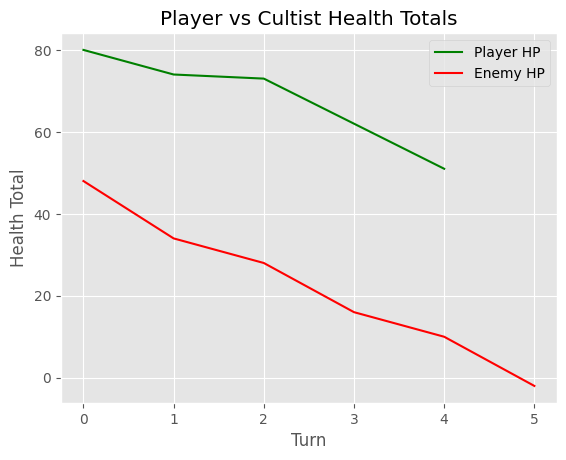

In [42]:
plt.plot(range(turns), player_hp_change, color='g', label='Player HP')
try:
    plt.plot(range(turns), enemy_hp_change, color='r', label='Enemy HP')
except:
    plt.plot(range(turns+1), enemy_hp_change, color='r', label='Enemy HP')

plt.title('Player vs Cultist Health Totals')
plt.xlabel('Turn')
plt.ylabel('Health Total')
plt.legend()
plt.show()

Health totals are what occurs at the end of the enemy's turn!

Ex: Player health total at the turn 1 point is what it was *after* the enemy acted

In [43]:
num_sims = 50
player_hp_vals_std = np.zeros(num_sims)
turns_taken_vals_std = np.zeros(num_sims)

player_hp_vals_new = np.zeros(num_sims)
turns_taken_vals_new = np.zeros(num_sims)

for i in range(num_sims):
    starting_deck = {'Strike': 5, 'Defend': 4, 'Bash': 1}
    hand = []
    current_deck = starting_deck.copy()
    current_discard = starting_deck.copy()
    for card in current_discard:
        current_discard[card] = 0
    max_hp = 80
    curr_hp = max_hp
    enemy_hp = 48
    turn, hp, _, _ = main(hand, current_deck, current_discard, max_hp, curr_hp, enemy_hp, cultist_pgf)
    player_hp_vals_std[i] = hp
    turns_taken_vals_std[i] = turn

    starting_deck = {'Strike': 5, 'Defend': 4, 'Bash': 1, 'Bludgeon': 1}
    hand = []
    current_deck = starting_deck.copy()
    current_discard = starting_deck.copy()
    for card in current_discard:
        current_discard[card] = 0
    max_hp = 80
    curr_hp = max_hp
    enemy_hp = 48
    turn, hp, _, _ = main(hand, current_deck, current_discard, max_hp, curr_hp, enemy_hp, cultist_pgf)
    player_hp_vals_new[i] = hp
    turns_taken_vals_new[i] = turn

In [44]:
print(f'Average turns taken with standard deck: {np.average(turns_taken_vals_std)}')
print(f'Average turns taken with new deck: {np.average(turns_taken_vals_new)}')
print(f'Average player health with standard deck: {np.average(player_hp_vals_std)}')
print(f'Average player health with new deck: {np.average(player_hp_vals_new)}')

Average turns taken with standard deck: 5.18
Average turns taken with new deck: 5.74
Average player health with standard deck: 43.98
Average player health with new deck: 29.44
